Librerías y Funciones propias:

In [38]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.goertzel import goertzel

Simulation:

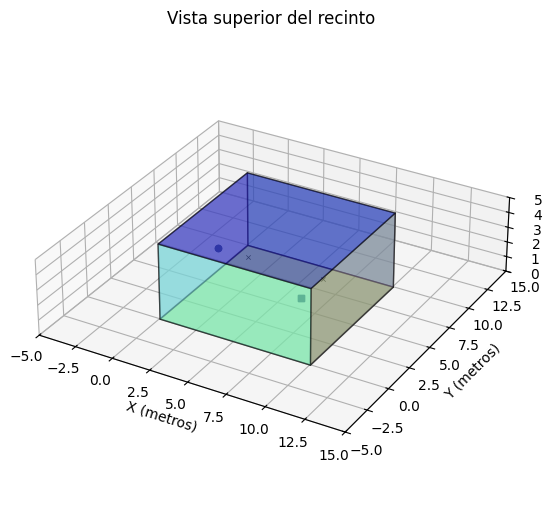

In [39]:
# Sampling frequency
fs = 48000 

# Room dimensions (width*length)
roomDimensions = [10, 10, 5]

# Create a room
room = pra.ShoeBox(roomDimensions, fs=fs, max_order=0)

# Sound source position (x,y,z)
sourcePosition = [1, 5, 2.5]
room.add_source(sourcePosition)

# Controller speaker position (x,y,z)
controllerSpeakerPosition = [8, 2.5, 2.5]
room.add_source(controllerSpeakerPosition)

# Reference microphone
referenceMicPosition = [3, 5, 2.5]

# Error microphone
errorMicPosition = [8, 5, 2.5]

# Add microphones to the room
room.add_microphone(referenceMicPosition, fs=fs)
room.add_microphone(errorMicPosition, fs=fs)

fig, ax = room.plot()
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
ax.set_aspect('equal')
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()


Obtain RIRs:

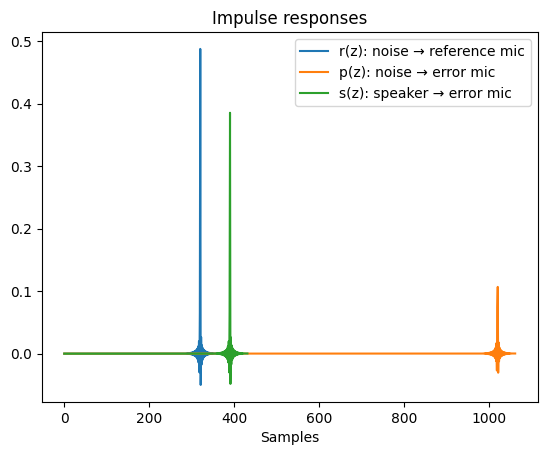

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
362
1062
432


In [40]:
room.compute_rir()
rir_r = room.rir[0][0]   # noise → reference mic
rir_p = room.rir[1][0]   # noise → error mic
rir_s = room.rir[1][1]   # speaker → error mic

plt.figure()
plt.plot(rir_r, label='r(z): noise → reference mic')
plt.plot(rir_p, label='p(z): noise → error mic')
plt.plot(rir_s, label='s(z): speaker → error mic')
plt.legend()
plt.title("Impulse responses")
plt.xlabel("Samples")
plt.show()

delay_r = np.argmax(np.abs(rir_r))
delay_p = np.argmax(np.abs(rir_p))
delay_s = np.argmax(np.abs(rir_s))

print("Delay R:", delay_r * 1000 / fs, "ms")
print("Delay P:", delay_p * 1000 / fs, "ms")
print("Delay S:", delay_s * 1000 / fs, "ms")

print("In order to comply with causality, computational time must be smaller than:", (delay_p * 1000 / fs) - (delay_r * 1000 / fs) - (delay_s * 1000 / fs), "ms")

print(len(rir_r))
print(len(rir_p))
print(len(rir_s))


Adaptive Harmonic Control

In [ ]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 100
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
noiseFrequency = 20
x = 10*np.sin(2*np.pi*noiseFrequency*t + np.pi)

# Control signal initialization
uHarmonicR = 90
uHarmonicI = -3
uHarmonic = uHarmonicR + 1j * uHarmonicI
mu = 5e-4

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = rir_s
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []
sHatAtNoiseFrequency = goertzel(s, noiseFrequency, fs)
print(sHatAtNoiseFrequency)

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Synthesize control signal block
    yBlock = np.real(uHarmonic * np.exp(1j * (2*np.pi*noiseFrequency/fs) * np.arange(k*blocklength, (k+1)*blocklength)))

    # Secondary path
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlock, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fyBlockOutput)

    # Error signal
    e = pBlockOutput + fyBlockOutput

    # Adapt control signal (LMS)
    E = goertzel(e, noiseFrequency, fs)
    E *= np.exp(-1j * (2*np.pi*noiseFrequency/fs) * k * blocklength)
    uHarmonic += mu * np.conj(sHatAtNoiseFrequency) * E

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

samples_to_plot = 50 * blocklength
start = N - samples_to_plot

t_plot = np.arange(samples_to_plot) / fs

primary = np.concatenate(pOutputBlocks)[start:]
secondary = np.concatenate(sOutputBlocks)[start:]
error = e_hist[start:]

plt.figure(figsize=(10,6))

plt.plot(t_plot, primary, label="Primary (ruido en mic)")
plt.plot(t_plot, secondary, label="Secondary (antiruido)")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Adaptive Harmonic Control")
plt.legend()
plt.grid(True)
plt.show()



Note:

This inmplementation is block based, but uses the Goertzel algorithm which performs the following filter:

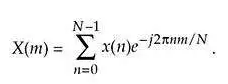

But the currect Goertzel helper function interprets the passed block as if n=0, so that is actually performs:

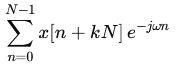

So it is necessary to align in time the exponential function with x[n] based on the current block:

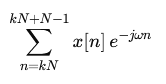

In code, this is done by multypling the result of the groetzel algorithm by np.exp(-1j * (2*np.pi*noiseFrequency/fs) * k * blocklength), based on the following deduction. If m = n - kN:

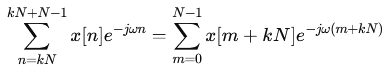

and the exponent can be taken out of the sum:

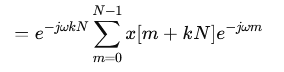

